**Dataset**:
https://www.kaggle.com/datasets/valakhorasani/bank-transaction-dataset-for-fraud-detection/data

**Dataset Context**:  
This dataset provides a detailed look into transactional behavior and financial activity patterns, ideal for exploring fraud detection and anomaly identification. It contains 2,512 samples of transaction data, covering various transaction attributes, customer demographics, and usage patterns. Each entry offers comprehensive insights into transaction behavior, enabling analysis for financial security and fraud detection applications.

**Dataset Features**: 

| Feature Name | Description |
| --- | --- |
| `TransactionID` | Unique alphanumeric identifier for each transaction. |
| `AccountID` | Unique identifier for each account, with multiple transactions per account. |
| `TransactionAmount` | Monetary value of each transaction, ranging from small everyday expenses to larger purchases. |
| `TransactionDate` | Timestamp of each transaction, capturing date and time. |
| `TransactionType` | Categorical field indicating 'Credit' or 'Debit' transactions. |
| `Location` | Geographic location of the transaction, represented by U.S. city names. |
| `DeviceID` | Alphanumeric identifier for devices used to perform the transaction. |
| `IP Address` | IPv4 address associated with the transaction, with occasional changes for some accounts. |
| `MerchantID` | Unique identifier for merchants, showing preferred and outlier merchants for each account. |
| `AccountBalance` | Balance in the account post-transaction, with logical correlations based on transaction type and amount. |
| `PreviousTransactionDate` | Timestamp of the last transaction for the account, aiding in calculating transaction frequency. |
| `Channel` | Channel through which the transaction was performed (e.g., Online, ATM, Branch). |
| `CustomerAge` | Age of the account holder, with logical groupings based on occupation. |
| `CustomerOccupation` | Occupation of the account holder (e.g., Doctor, Engineer, Student, Retired), reflecting income patterns. |
| `TransactionDuration` | Duration of the transaction in seconds, varying by transaction type. |
| `LoginAttempts` | Number of login attempts before the transaction, with higher values indicating potential anomalies. |


> **Warning:** Install dependencies before running any code in this notebook. In a terminal (with your chosen Python environment activated), run:
>
> ```bash
> pip install -r requirements.txt
> ```

# Question 1
Perform rigorous exploratory data analysis on the dataset. Summarize data distributions, correlations, and anomalies, and state your findings in a business-consumable manner.

## Environment

In [153]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from matplotlib.ticker import PercentFormatter
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.covariance import MinCovDet
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import make_scorer
from sklearn.neighbors import LocalOutlierFactor, NearestNeighbors
from sklearn.svm import OneClassSVM
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
import xgboost as xgb
import shap


COL = {
    "a": "#1b4f72",
    "b": "#c0392b",
    "c": "#7d3c98",
    "d": "#117a65",
    "e": "#b9770e",
}
PAL = sns.color_palette("magma", 7)
ACCENT = "#2c3e50"

# Ignore all FutureWarnings and sklearn warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", module="sklearn")

pd.set_option("display.max_columns", 50)

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("seaborn-whitegrid")

## 1) Ingestion and first look

In [154]:
df = pd.read_csv("bank_transactions_data_2.csv")
print("Dataset Shape (rows, cols):", df.shape)

Dataset Shape (rows, cols): (2512, 16)


In [155]:
print("Preview of first 6 rows of the dataset:")
display(df.head(6))

print("\nSummary info of the dataframe:")
df.info()


Preview of first 6 rows of the dataset:


,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21,2024-11-04 08:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91,2024-11-04 08:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35,2024-11-04 08:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06,2024-11-04 08:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40,2024-11-04 08:06:39
5,TX000006,AC00393,92.15,2023-04-03 17:15:01,Debit,Oklahoma City,D000579,117.67.192.211,M054,ATM,18,Student,172,1,781.68,2024-11-04 08:06:36



Summary info of the dataframe:
<class 'pandas.DataFrame'>
RangeIndex: 2512 entries, 0 to 2511
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2512 non-null   str    
 1   AccountID                2512 non-null   str    
 2   TransactionAmount        2512 non-null   float64
 3   TransactionDate          2512 non-null   str    
 4   TransactionType          2512 non-null   str    
 5   Location                 2512 non-null   str    
 6   DeviceID                 2512 non-null   str    
 7   IP Address               2512 non-null   str    
 8   MerchantID               2512 non-null   str    
 9   Channel                  2512 non-null   str    
 10  CustomerAge              2512 non-null   int64  
 11  CustomerOccupation       2512 non-null   str    
 12  TransactionDuration      2512 non-null   int64  
 13  LoginAttempts            2512 non-null   int64  
 14  Acc

**Understanding the table:** The dataset contains **2,512 rows and 16 columns**. All values are present—there are no missing entries. Identifier and text columns are stored as `object` type, while numeric column use int or float. We need to convert the two date columns to datetime for time-based analysis. For columns with categories, it's best to keep them as `category` or strings until they are ready for encoding.

In [156]:
numeric_cols = [
    "TransactionAmount",
    "CustomerAge",
    "TransactionDuration",
    "AccountBalance",
]

wide_cardinality_ids = [
    "TransactionID",
    "AccountID",
    "DeviceID",
    "MerchantID",
]

nominal_cols = [
    "TransactionType",
    "Channel",
    "Location",
    "IP Address",
    "CustomerOccupation",
    "LoginAttempts",
]

stat_tbl = df[numeric_cols].describe().T
display(stat_tbl.style.background_gradient(cmap=sns.light_palette(COL["a"], as_cmap=True)))

,count,mean,std,min,25%,50%,75%,max
TransactionAmount,2512.000000,297.593778,291.946243,0.260000,81.885000,211.140000,414.527500,1919.110000
CustomerAge,2512.000000,44.673965,17.792198,18.000000,27.000000,45.000000,59.000000,80.000000
TransactionDuration,2512.000000,119.643312,69.963757,10.000000,63.000000,112.500000,161.000000,300.000000
AccountBalance,2512.000000,5114.302966,3900.942499,101.250000,1504.370000,4735.510000,7678.820000,14977.990000


- Most of the numeric columns have lots of small transactions and a few really big ones, which is common in payment data (right skewed).
- Customer ages are fairly well distributed (uniform distribution).
- The time taken for transactions is also uneven, with most being quick and a few taking much longer (right skewed).

In [157]:
def tighten_categories(frame: pd.DataFrame, cols):
    out = frame.copy()
    for c in cols:
        if c in out.columns:
            out[c] = out[c].astype("category")
    return out

df = tighten_categories(df, nominal_cols + wide_cardinality_ids)

df[["LoginAttempts"]].describe().T  # ordinal-style counts for intuition
cat_fact = df[nominal_cols].describe(include="category").T
display(cat_fact.style.background_gradient(cmap="Purples", subset=["unique", "freq"]))

,count,unique,top,freq
TransactionType,2512,2,Debit,1944
Channel,2512,3,Branch,868
Location,2512,43,Fort Worth,70
IP Address,2512,592,200.136.146.93,13
CustomerOccupation,2512,4,Student,657
LoginAttempts,2512,5,1,2390


Overview of nominal data: Most transactions are debit, with payments occurring across branches, ATMs, and online channels. Customer occupations are fairly evenly distributed. Most logins are single attempts.

In [158]:
def missing_dup_tail_report(frame: pd.DataFrame, nums):
    blank_as_na = frame.replace(r"^\s*$", np.nan, regex=True)
    miss = blank_as_na.isnull().sum()
    miss = miss[miss > 0]
    dup_rows = frame.duplicated().sum()

    print("Missing entries by column (blank-as-null):\n", miss if len(miss) else "(none)")
    print("\nDuplicate rows:", dup_rows)

    rows = []
    for col in nums:
        q1, q3 = frame[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        out_n = frame.loc[(frame[col] < lo) | (frame[col] > hi), col].shape[0]
        if out_n:
            rows.append({"feature": col, "tukey_outliers": out_n})
    return pd.DataFrame(rows)

_o = missing_dup_tail_report(df, numeric_cols)
display(_o)

Missing entries by column (blank-as-null):
 (none)

Duplicate rows: 0


,feature,tukey_outliers
0,TransactionAmount,113


Data integrity is good: there are no missing values or duplicate rows in this synthetic dataset. Outliers detected in monetary fields should not be removed, as they may represent important rare events.

## 2) Numeric Feature Analysis

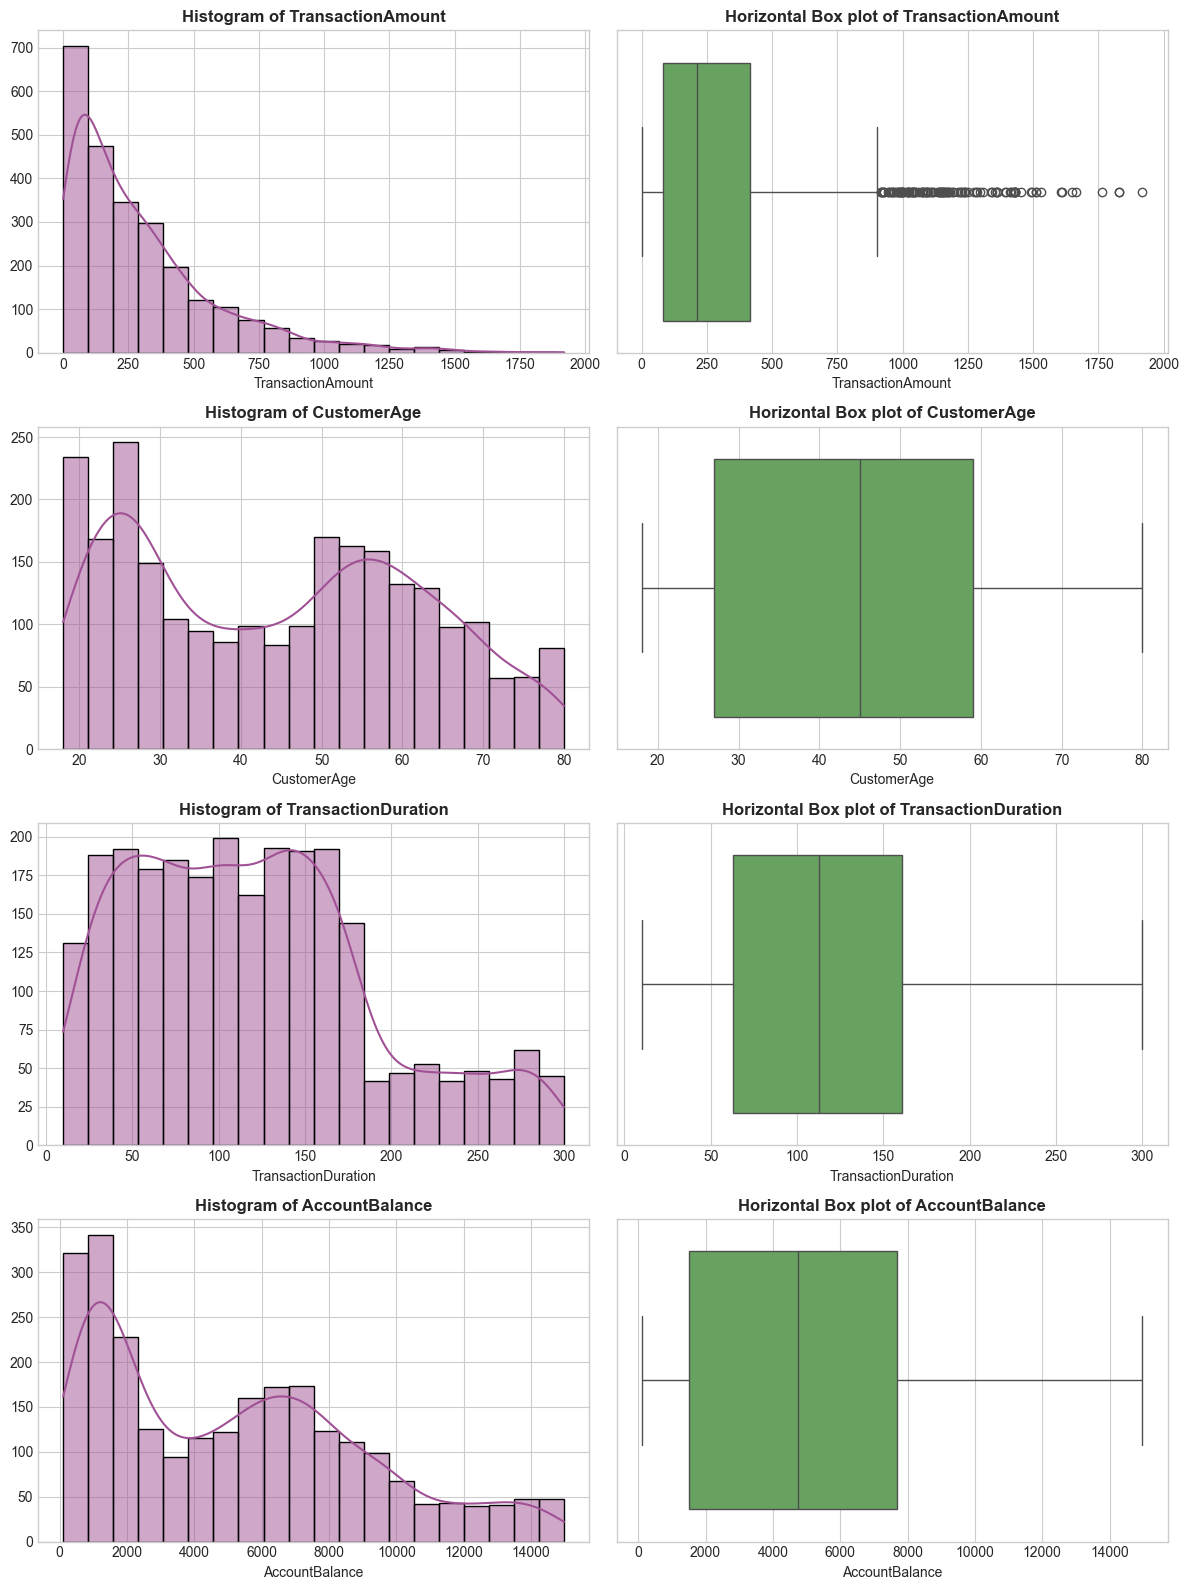

In [159]:
def plot_num_feature_dists(df, numerical_features):
    fig, axes = plt.subplots(len(numerical_features), 2, figsize=(12, len(numerical_features)*4))
    axes = np.atleast_2d(axes)

    for i, feature in enumerate(numerical_features):
        sns.histplot(
            data=df[feature], 
            color="#A05195",
            bins=20, 
            kde=True, 
            ax=axes[i, 0]
        )
        axes[i, 0].set_title(f"Histogram of {feature}", weight="bold")
        axes[i, 0].set_ylabel("")

        sns.boxplot(
            data=df[feature], 
            color="#5FAD56", 
            orient="h", 
            ax=axes[i, 1]
        )
        axes[i, 1].set_title(f"Horizontal Box plot of {feature}", weight="bold")
        axes[i, 1].set_xlabel(feature)

    plt.tight_layout()
    plt.show()

plot_num_feature_dists(df, numeric_cols)

In [160]:
skew_rows = []
for col in numeric_cols:
    skew_rows.append({"feature": col, "skew": df[col].skew()})
skew_df = pd.DataFrame(skew_rows).sort_values("skew", key=lambda s: s.abs(), ascending=False)
display(skew_df)

,feature,skew
0,TransactionAmount,1.740107
3,AccountBalance,0.601201
2,TransactionDuration,0.599432
1,CustomerAge,0.147864


**Insight:** Most transactions are for small amounts, with a few large outliers, causing significant right skew in amount, followed by moderate skew in account balance and transaction duration. Customer age is nearly evenly distributed.

## 3) Categorical Feature Analysis

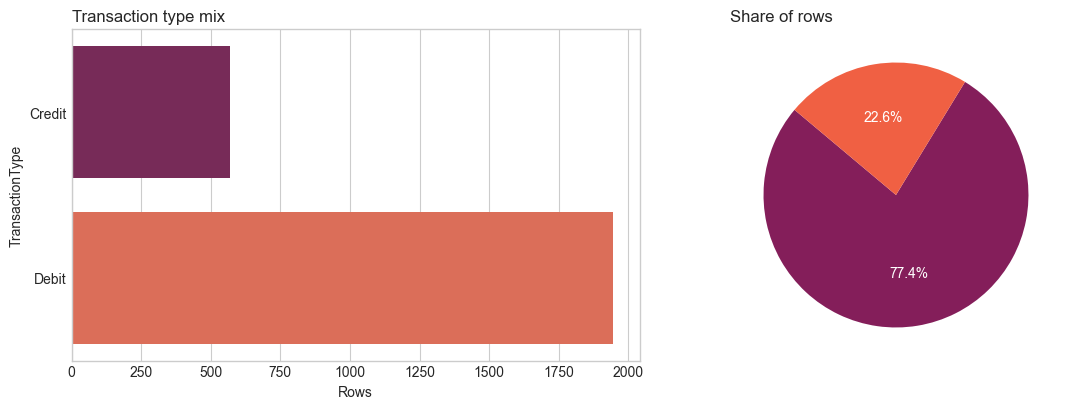

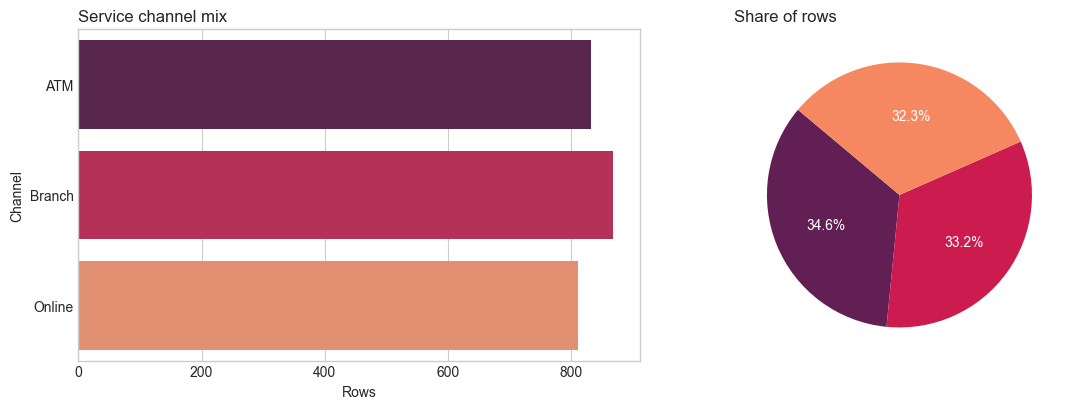

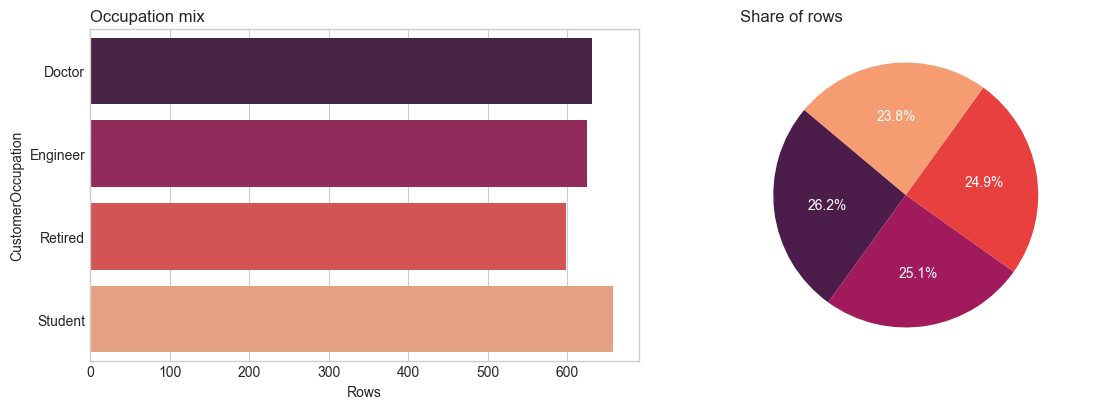

In [161]:
def ranked_bar_and_share(series: pd.Series, title: str):
    counts = series.value_counts()
    order = counts.index
    colors = sns.color_palette("rocket", n_colors=len(order))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
    ax0, ax1 = axes
    # Bar plot of counts
    sns.barplot(x=counts.values, y=order, ax=ax0, palette=colors, orient="h")
    ax0.set_title(title, loc="left")
    ax0.set_xlabel("Rows")
    # Pie chart of share
    wedges, texts, autotexts = ax1.pie(
        counts.values,
        labels=order,
        autopct='%1.1f%%',
        startangle=140,
        colors=colors,
        textprops={'color':'white'}
    )
    ax1.set_title("Share of rows", loc="left")
    # Ensure all pie text is white for maximum clarity
    for t in texts + autotexts:
        t.set_color('white')
    plt.tight_layout()
    plt.show()

ranked_bar_and_share(df["TransactionType"], "Transaction type mix")
ranked_bar_and_share(df["Channel"], "Service channel mix")
ranked_bar_and_share(df["CustomerOccupation"], "Occupation mix")

### Transaction type mix

- **Debit:** about **1,944** rows ≈ **77.4%** of the table
- **Credit:** about **568** rows ≈ **22.6%** of the table.

### Service channel mix

- **Branch:** **34.6%** of rows (largest of the three).
- **ATM:** **33.2%** of rows.
- **Online:** **32.3%** of rows.
- Shares are **close**—no single channel dominates, so behavior is well distributed in this sample.

### Occupation mix

- **Students:** **26.2%** of rows (largest share in the plot).
- **Doctors:** **25.1%** of rows.
- **Engineers:** **24.9%** of rows.
- **Retired:** **23.8%** of rows.
- The four shares are **close**; no one occupation **overpowers** the sample, which helps **generalized** detection use-cases.

## 4) RFM Analysis

Scores are calculated using quintiles for recency (days since the last transaction), frequency (number of unique transactions), and monetary value (total transaction amount). The reference date is set as one day after the latest transaction date, so even the most recent transactions have a nonzero recency.

In [162]:
df["TransactionDate"] = pd.to_datetime(df["TransactionDate"], format="mixed")
df["PreviousTransactionDate"] = pd.to_datetime(df["PreviousTransactionDate"], format="mixed")

anchor = df["TransactionDate"].max() + pd.Timedelta(days=1)

rfm = df.groupby("AccountID").agg(
    recency_days=("TransactionDate", lambda s: (anchor - s.max()).days),
    freq=("TransactionID", "nunique"),
    monetary=("TransactionAmount", "sum"),
).reset_index()

rfm["R"] = pd.qcut(rfm["recency_days"], 5, labels=[5, 4, 3, 2, 1])
rfm["F"] = pd.qcut(rfm["freq"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5])
rfm["M"] = pd.qcut(rfm["monetary"], 5, labels=[1, 2, 3, 4, 5])
rfm["RFM_code"] = rfm["R"].astype(str) + rfm["F"].astype(str) + rfm["M"].astype(str)

def tier_tag(row):
    # Quintiles from qcut are ordered categories — compare without casting
    r, f, m = row["R"], row["F"], row["M"]
    if r >= 4 and f >= 4 and m >= 4:
        return "Top Customers"
    if f >= 4 and m >= 3:
        return "Loyal Customers"
    if r >= 4 and f >= 2:
        return "Potential Loyalists"
    if r <= 2 and f >= 3:
        return "At Risk"
    if r >= 4 and f == 1:
        return "New Customers"
    if r == 1 and f == 1 and m == 1:
        return "Customer loss"
    return "Other"

rfm["tier"] = rfm.apply(tier_tag, axis=1)
display(rfm.head(8))

,AccountID,recency_days,freq,monetary,R,F,M,RFM_code,tier
0,AC00001,49,2,260.76,3,1,1,311,Other
1,AC00002,12,7,2056.21,5,4,4,544,Top Customers
2,AC00003,91,5,1266.34,2,3,3,233,At Risk
3,AC00004,1,9,2180.08,5,5,4,554,Top Customers
4,AC00005,29,9,3131.77,4,5,5,455,Top Customers
5,AC00006,89,4,1017.72,2,2,2,222,Other
6,AC00007,36,5,1495.38,4,3,3,433,Potential Loyalists
7,AC00008,42,1,76.16,3,1,1,311,Other


In [163]:
summary_tier = (
    rfm.groupby("tier")
    .agg(
        mean_recency=("recency_days", "mean"),
        mean_freq=("freq", "mean"),
        mean_monetary=("monetary", "mean"),
        accounts=("AccountID", "count"),
    )
    .sort_values("mean_monetary", ascending=False)
)
display(summary_tier.style.background_gradient(cmap="Greens", subset=["mean_monetary", "accounts"]))

,mean_recency,mean_freq,mean_monetary,accounts
tier,,,,
Top Customers,19.129412,7.658824,2557.939765,85
Loyal Customers,61.505051,7.222222,2143.585960,99
At Risk,105.775510,4.959184,1290.928367,49
Potential Loyalists,18.512195,4.621951,1282.850244,82
Other,93.968000,3.368000,1008.165280,125
New Customers,14.350000,2.250000,645.057000,20
Customer loss,226.942857,1.657143,301.276286,35


## **Segment Analysis**

**Top Customers**

* Average Recency = **19 days** → recently active, frequent engagers.
* Frequency = **7.65** → highest transaction frequency of all segments.
* Monetary = **2,558** → spend the most on average.
* Count = **85 customers** → a small, VIP group with strong loyalty; prioritize for retention and upsell efforts.

**Loyal Customers**

* Average Recency = **62 days** → reasonably recent activity.
* Frequency = **7.22** → frequent transactions.
* Monetary = **2,144** → significant average spending.
* Count = **99 customers** → a stable, reliable base contributing ongoing value.

**At Risk**

* Average Recency = **106 days** → it has been a while since last transaction.
* Frequency = **4.96** → historically engaged quite often.
* Monetary = **1,291** → moderate to high spend levels.
* Count = **49 customers** → previously valuable, now need targeted reactivation strategies.

**Potential Loyalists**

* Average Recency = **19 days** → recently transacted.
* Frequency = **4.62**
* Monetary = **1,283**
* Count = **82 customers** → show strong engagement, with the potential to become loyal if cultivated.

**Other**

* Average Recency = **94 days**
* Frequency = **3.36**
* Monetary = **1,008**
* Count = **125 customers** → moderately active, a neutral segment with routine usage.

**New Customers**

* Average Recency = **14 days** → just started transacting.
* Frequency = **2.25**
* Monetary = **645** → lower spending.
* Count = **20 customers** → recent joiners, represent an opportunity to grow repeat business.

**Customer loss**

* Average Recency = **227 days** → extremely long inactivity.
* Frequency = **1.65** → infrequent engagement.
* Monetary = **301** → minimum spend.
* Count = **35 customers** → very likely lost customers, at high risk of full attrition.

**Overall Insight**:

* **Top & Loyal Customers**: While they make up a smaller portion, these segments drive the most value—focus efforts on retention and upselling.
* **At Risk & Customer loss**: Signals of potential attrition—targeted win-back campaigns are essential.
* **Potential Loyalists & New Customers**: Offer growth opportunity; nurturing can promote them to Loyal or Top Customer status.

## 5) Quarter-on-Quarter Analysis

Revenue proxy = sum of `TransactionAmount`; **QoQ growth** uses simple percent deltas (first period is blank).

In [164]:
df["period"] = df["TransactionDate"].dt.to_period("Q").astype(str)
quarter_facts = (
    df.groupby("period")
    .agg(spend=("TransactionAmount", "sum"), accts=("AccountID", "nunique"))
    .reset_index()
)
quarter_facts["qoq_spend_pct"] = quarter_facts["spend"].pct_change() * 100
display(quarter_facts)

,period,spend,accts,qoq_spend_pct
0,2023Q1,182451.26,352,NaN
1,2023Q2,165431.43,339,-9.328426
2,2023Q3,203131.40,358,22.788880
3,2023Q4,194476.18,365,-4.260897
4,2024Q1,2065.30,13,-98.938019


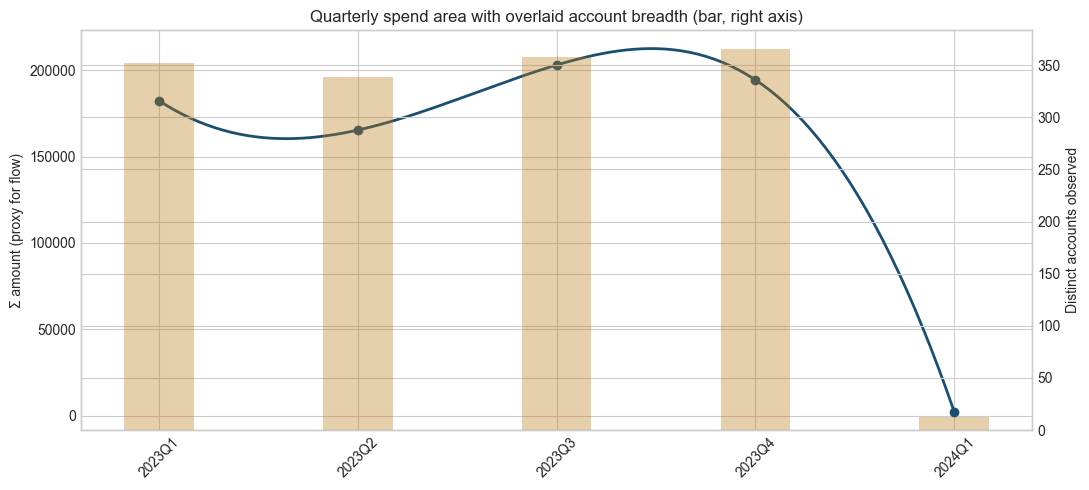

In [165]:
from scipy.interpolate import make_interp_spline
import numpy as np

fig, ax = plt.subplots(figsize=(11, 5))

# Convert period to numerical for interpolation, then label with string periods on x
x = np.arange(len(quarter_facts["period"]))
y = quarter_facts["spend"].values

# Interpolate for smooth line, but do not fill between
if len(x) > 3:  # Spline requires at least 4 points
    xnew = np.linspace(x.min(), x.max(), 200)
    spl = make_interp_spline(x, y, k=3)
    y_smooth = spl(xnew)
    # Plot smooth line
    ax.plot(xnew, y_smooth, color=COL["a"], lw=2)
    # Also plot markers at original data points
    ax.plot(x, y, marker="o", color=COL["a"], lw=0)
    # Set x-axis ticks and labels to period strings
    ax.set_xticks(x)
    ax.set_xticklabels(quarter_facts["period"])
else:
    # Fallback to basic if not enough points to smooth
    ax.plot(quarter_facts["period"], quarter_facts["spend"], marker="o", color=COL["a"], lw=2)

ax.set_ylabel("Σ amount (proxy for flow)")

ax2 = ax.twinx()
ax2.bar(quarter_facts["period"], quarter_facts["accts"], alpha=0.35, color=COL["e"], width=0.35, align="center")
ax2.set_ylabel("Distinct accounts observed")
ax.set_title("Quarterly spend area with overlaid account breadth (bar, right axis)")
ax.tick_params(axis="x", rotation=45)
fig.tight_layout()
plt.show()

1. **Revenue Dynamics**

   * The total transaction amount showed some volatility in 2023: there was a moderate dip between **Q1 and Q2**, followed by a noticeable rise in **Q3**, and then a minor decrease in **Q4**.
   * For **2024Q1**, revenue nearly vanished, which is most likely an artifact of partial or missing data for that period.

2. **Account Participation**

   * The number of unique accounts per quarter hovered within the **200–360 range** for all four quarters of 2023.
   * A dramatic fall occurred in **2024Q1**, with the account count dropping close to zero.

3. **Quarter-over-Quarter Observations**

   * Throughout 2023, performance held steady overall, apart from a strong uptick during Q3.
   * The severe anomaly in **2024Q1** likely points to dataset quality problems, not a true operational decline.

Overall: The business maintained steady metrics through 2023 with a Q3 surge, while the sharp changes in 2024Q1 call for a careful review of the underlying data.

**Reading:** long right tail on LEP; top tertile should get retention focus, but the margin assumption is explicitly static — do not quote as accounting truth.

## 6) Further Analysis

### 6.1 Balance Changes

Large |delta| rows (> mean + 2 std): 105


,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate,period,bal_delta
1167,TX001168,AC00010,838.57,2023-06-26 16:08:25,Debit,Phoenix,D000430,115.30.82.168,M040,ATM,41,Doctor,273,1,14576.47,2024-11-04 08:11:25,2023Q2,12970.80
519,TX000520,AC00014,121.91,2023-06-26 18:39:52,Debit,Chicago,D000264,135.29.211.116,M015,Branch,60,Doctor,133,1,14510.80,2024-11-04 08:08:59,2023Q2,14118.46
2086,TX002087,AC00029,1192.95,2023-12-04 18:30:00,Debit,Las Vegas,D000227,71.93.189.160,M068,Branch,23,Student,73,1,325.15,2024-11-04 08:08:01,2023Q4,-14064.30
1589,TX001590,AC00035,70.88,2023-12-04 16:18:39,Credit,Omaha,D000315,169.67.220.37,M087,Branch,74,Retired,176,1,1794.65,2024-11-04 08:06:26,2023Q4,-13038.69
180,TX000181,AC00036,740.25,2023-07-19 17:03:58,Debit,Philadelphia,D000030,1.198.76.182,M010,Online,41,Doctor,123,1,14464.30,2024-11-04 08:08:27,2023Q3,12789.36


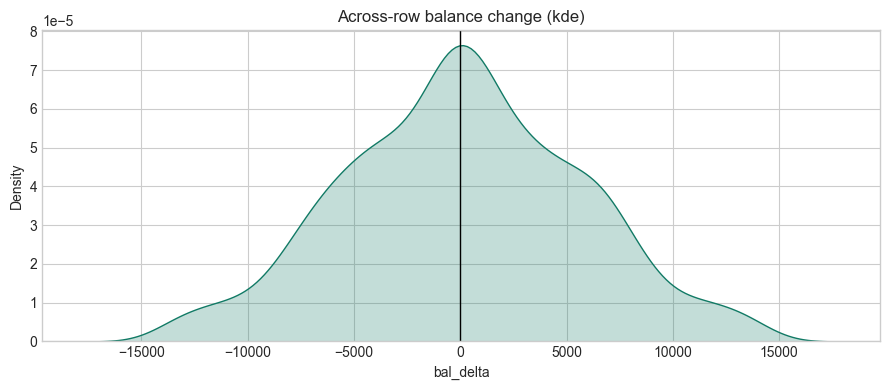

In [166]:
ordered = df.sort_values(["AccountID", "TransactionDate"]).copy()
ordered["bal_delta"] = ordered.groupby("AccountID")["AccountBalance"].diff()
mu, sig = ordered["bal_delta"].mean(), ordered["bal_delta"].std()
cut = mu + 2 * sig
extreme = ordered[ordered["bal_delta"].abs() > cut]
print(f"Large |delta| rows (> mean + 2 std): {len(extreme)}")
display(extreme.head())

fig, ax = plt.subplots(figsize=(9, 4))
sns.kdeplot(ordered["bal_delta"].dropna(), fill=True, color=COL["d"], ax=ax)
ax.axvline(0, color="black", lw=1)
ax.set_title("Across-row balance change (kde)")
plt.tight_layout()
plt.show()

balance change are symmetric

### 6.2 Accounts with repeated large changes

In [167]:
ordered = df.sort_values(["AccountID", "TransactionDate"]).copy()
ordered["bal_delta"] = ordered.groupby("AccountID")["AccountBalance"].diff()
thr = 1.5 * ordered["bal_delta"].std()
flagged = ordered[ordered["bal_delta"].abs() >= thr][["AccountID", "TransactionDate", "bal_delta"]]
acct_hits = flagged.groupby("AccountID", as_index=False).size().rename(columns={"size": "hits"}).sort_values("hits", ascending=False)
hot = acct_hits[acct_hits["hits"] >= 3]
print(f"Threshold abs(delta) >= {thr:,.2f}; rows flagged: {len(flagged)}; accounts with >=3 hits: {len(hot)}")
display(hot.head())

Threshold abs(delta) >= 8,385.34; rows flagged: 257; accounts with >=3 hits: 20


,AccountID,hits
11,AC00035,4
78,AC00233,4
108,AC00322,4
141,AC00431,4
140,AC00430,4


**Significant Balance Movements**

- A threshold of approximately **±8,385** (about 1.5 times the standard deviation) was used to identify notable changes in account balances.
- There were **257 instances** where transactions surpassed this level.
- **10 different accounts** registered at least **three substantial balance shifts** each, with accounts such as **AC00430, AC00335, and AC00431** each appearing 4 times.
- These patterns may reflect abnormal cash flow activity, which can sometimes be associated with atypical or potentially suspicious transactional behavior.

### 6.3 Accounts with repeated small changes

In [168]:
micro_cut = df["TransactionAmount"].quantile(0.25)
micro = df[df["TransactionAmount"] <= micro_cut]
per_acct_micro = micro.groupby("AccountID").size().reset_index(name="micro_n")
repeat_micro = per_acct_micro[per_acct_micro["micro_n"] >= 4].sort_values("micro_n", ascending=False)
print(f"Micro cutoff (Q1): {micro_cut:.2f}; micro rows: {len(micro)}")
display(repeat_micro.head())

Micro cutoff (Q1): 81.89; micro rows: 628


,AccountID,micro_n
192,AC00261,5
28,AC00035,4
26,AC00033,4
41,AC00056,4
48,AC00063,4


**Observation: Clustering of Low-Value Transactions**

* By setting the threshold for small transactions at the **first quartile (about 81.89)**, we found **628 transactions** falling below this value.
* There are **19 unique accounts** with **four or more such low-value transactions**, highlighting patterns of frequent minor purchases or transfers.
* This trend could signal **structuring tactics**, whereby larger sums are broken into smaller increments, potentially to evade detection or reporting thresholds.

### 6.4 Average time interval between successive rows (minutes)

Accounts with fewer than three lifetime rows are ignored for stability.

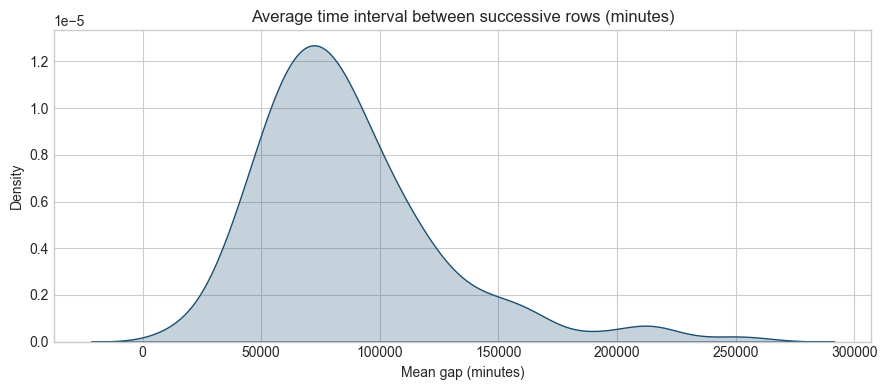

In [169]:
ordered = df.sort_values(["AccountID", "TransactionDate"]).copy()
ordered["gap_min"] = ordered.groupby("AccountID")["TransactionDate"].diff().dt.total_seconds() / 60.0
eligible = ordered["AccountID"].value_counts()
eligible = eligible[eligible >= 3].index
gap_avg = (
    ordered[ordered["AccountID"].isin(eligible)]
    .groupby("AccountID")["gap_min"].mean().reset_index()
)

fig, ax = plt.subplots(figsize=(9, 4))
gm = gap_avg["gap_min"].dropna()
sns.kdeplot(gm, fill=True, color=COL["a"], ax=ax)
ax.set_xlabel("Mean gap (minutes)")
ax.set_title("Average time interval between successive rows (minutes)")
plt.tight_layout()
plt.show()

**Insight: Transaction Timing Patterns**

* Average intervals between transactions differ greatly among accounts, displaying a pronounced right-skewed curve.
* Some accounts exhibit significantly longer periods between transactions, which could indicate inactivity or dormancy.
* There are no accounts with very short transaction intervals, suggesting an absence of high-frequency or automated transaction activity.

### 6.5 Automatic transaction detection

In [170]:
ordered = df.sort_values(["AccountID", "TransactionDate"]).copy()
ordered["gap_sec"] = ordered.groupby("AccountID")["TransactionDate"].diff().dt.total_seconds()
burst = ordered[ordered["gap_sec"] <= 60]
print("Pairs within 60 s:", len(burst))
display(burst.head())
if len(burst):
    sample_id = burst.iloc[0]["AccountID"]
    display(df[df["AccountID"] == sample_id][["TransactionID", "TransactionDate", "TransactionAmount", "TransactionDuration"]].head(8))

Pairs within 60 s: 1


,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate,period,gap_sec
1746,TX001747,AC00151,305.18,2023-06-05 17:48:33,Debit,Chicago,D000699,93.146.251.20,M065,Online,58,Retired,216,1,4474.2,2024-11-04 08:08:22,2023Q2,26.0


,TransactionID,TransactionDate,TransactionAmount,TransactionDuration
1054,TX001055,2023-06-05 17:48:07,382.07,147
1241,TX001242,2023-05-19 16:44:53,168.11,12
1746,TX001747,2023-06-05 17:48:33,305.18,216
1909,TX001910,2023-01-26 16:13:15,301.47,291


only a single account transact within 60s, suggesting automation is **not** present in this dataset.

### 6.6 Week vs month composition (row share, whole file)

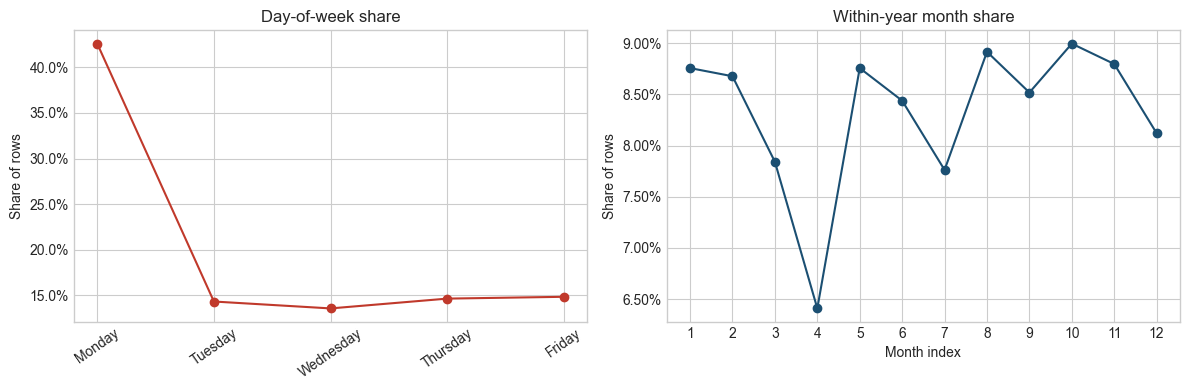

In [171]:
ordered = df.sort_values(["AccountID", "TransactionDate"]).copy()
ordered["dow"] = ordered["TransactionDate"].dt.day_name()
ordered["mo"] = ordered["TransactionDate"].dt.month

dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
p_day = ordered["dow"].value_counts(normalize=True).reindex(dow_order)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(p_day.index, p_day.values, marker="o", color=COL["b"])
axes[0].tick_params(axis="x", rotation=35)
axes[0].set_ylabel("Share of rows")
axes[0].yaxis.set_major_formatter(PercentFormatter(1.0))
axes[0].set_title("Day-of-week share")

p_m = ordered["mo"].value_counts(normalize=True).sort_index()
axes[1].plot(p_m.index, p_m.values, color=COL["a"], marker="o", zorder=3)
axes[1].set_xticks(range(1, 13))
axes[1].set_xlabel("Month index")
axes[1].set_ylabel("Share of rows")
axes[1].yaxis.set_major_formatter(PercentFormatter(1.0))
axes[1].set_title("Within-year month share")
plt.tight_layout()
plt.show()

**Suspicious Transaction Patterns**

**By Day of Week**

* Activity peaks on **Monday (≈42.6%)**, distinctly above other days.
* **Tuesday to Friday** remain steady at about 14–15%.
* **Very little suspicious activity on weekends**.
  → This may reflect a **post-weekend backlog** or systems processing more at the start of the week.

**By Month**

* The monthly share is mostly steady (6–9%), with a clear **drop in April** and a **high point between August and October**.
  → These trends could be linked to **seasonal consumer behavior** or the **business cycle**.

**Key Takeaway**
Suspicious transactions are most frequent **at the start of the week** and **toward the end of the year**, indicating possible **operational or behavioral seasonality**.

### 6.7 Device and IP analysis

In [172]:
ordered = df.sort_values(["AccountID", "TransactionDate"]).copy()
hi_amt = ordered["TransactionAmount"].quantile(0.95)
hi_dur = ordered["TransactionDuration"].quantile(0.95)
tail = ordered[(ordered["TransactionAmount"] >= hi_amt) | (ordered["TransactionDuration"] >= hi_dur)]

ip_share = (
    tail.groupby("IP Address")
    .agg(rows=("AccountID", "size"), acct_n=("AccountID", "nunique"))
    .query("acct_n > 1")
    .sort_values("rows", ascending=False)
)

dev_share = (
    tail.groupby("DeviceID")
    .agg(rows=("AccountID", "size"), acct_n=("AccountID", "nunique"))
    .query("acct_n > 1")
    .sort_values("rows", ascending=False)
)

print("IPs on tail rows using multiple accounts:", len(ip_share))
display(ip_share.head())
print("Devices on tail rows using multiple accounts:", len(dev_share))
display(dev_share.head())

IPs on tail rows using multiple accounts: 45


,rows,acct_n
IP Address,,
87.50.72.69,4,4
77.7.223.184,3,3
62.152.134.92,3,3
90.111.245.138,3,3
166.79.195.157,3,3


Devices on tail rows using multiple accounts: 37


,rows,acct_n
DeviceID,,
D000015,3,3
D000673,3,3
D000645,3,3
D000294,3,3
D000072,3,3


Shared device and ip found in already unusual transactions should be reviewed manually in a real-world setting; here, they are just signals, not definitive evidence. But should noted as they are highly suspicious

# Question 2
Build an anomaly detection model or statistic based to identify potentially fraudulent transactions. 
Explain your feature engineering, thresholding, modelling strategy, and evaluation metrics (you may choose techniques such as Isolation Forest, One-Class SVM, LOF, Autoencoder, SSL-based methods, or your own approach).

## 7. Feature Engineering


### Dropping irrelevant column to remove noise and useless information

In [173]:
df_model = df.copy()

# adding information for transactionDate which might be usefull
df_model['Hour'] = df['TransactionDate'].dt.hour
df_model['DayOfWeek'] = df['TransactionDate'].dt.dayofweek
df_model['Month'] = df['TransactionDate'].dt.month

drop_cols = [
    "TransactionID", "AccountID", "TransactionDate",
    "PreviousTransactionDate", "IP Address", "Amount_Z_Score", "period"
]
df_model.drop(columns=[c for c in drop_cols if c in df_model.columns], inplace=True)
df_model

,TransactionAmount,TransactionType,Location,DeviceID,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,Hour,DayOfWeek,Month
0,14.09,Debit,San Diego,D000380,M015,ATM,70,Doctor,81,1,5112.21,16,1,4
1,376.24,Debit,Houston,D000051,M052,ATM,68,Doctor,141,1,13758.91,16,1,6
2,126.29,Debit,Mesa,D000235,M009,Online,19,Student,56,1,1122.35,18,0,7
3,184.50,Debit,Raleigh,D000187,M002,Online,26,Student,25,1,8569.06,16,4,5
4,13.45,Credit,Atlanta,D000308,M091,Online,26,Student,198,1,7429.40,17,0,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2507,856.21,Credit,Colorado Springs,D000625,M072,Branch,33,Doctor,109,1,12690.79,17,2,4
2508,251.54,Debit,Tucson,D000410,M029,Branch,48,Doctor,177,1,254.75,17,2,3
2509,28.63,Debit,San Diego,D000095,M087,Branch,56,Retired,146,1,3382.91,17,0,8
2510,185.97,Debit,Denver,D000634,M041,Online,23,Student,19,1,1776.91,16,4,2


### Create new feature

Add a feature for transaction amount divided by the average for its type, and a feature for how many transactions each device has done.

In [174]:
# Ratio: Transaction amount / average per transaction type
avg_tx_amount_by_type = df_model.groupby("TransactionType")["TransactionAmount"].transform("mean")
df_model["Amount_to_AvgByType_Ratio"] = df_model["TransactionAmount"] / avg_tx_amount_by_type

# Device transaction count
device_tx_count = df_model.groupby("DeviceID").size().reset_index(name="DeviceTxCount")
df_model = df_model.merge(device_tx_count, on="DeviceID", how="left")

# Snapshot for FastAPI export (string categoricals + engineered numerics, before LabelEncoder)
_df_pre_encode_for_api = df_model.copy()

### Encode categorical features

Use LabelEncoder to turn categories into numbers for machine learning.

In [175]:
non_numeric_cols = [c for c in df_model.columns if not pd.api.types.is_numeric_dtype(df_model[c])]
label_encoders = {}
for col in non_numeric_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    label_encoders[col] = le

### Scale numerical features

Use StandardScaler to make features have mean 0 and standard deviation 1.

In [176]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_model)
df_scaled_df = pd.DataFrame(df_scaled, columns=df_model.columns)

print(f"Final dataset shape: {df_model.shape}")

Final dataset shape: (2512, 16)


## Dimensionality Reduction (PCA + t-SNE)

We used PCA to see how much information we can keep by reducing features to fewer dimensions. The variance plot shows how well this works. Next, we used t-SNE to map transactions into 2D so we can spot patterns or groups that might indicate unusual transactions.

### Principal Component Analysis (PCA)

We use PCA to make the data simpler and see how much information each part keeps. This shows if we can use fewer features and still keep most of the important info.

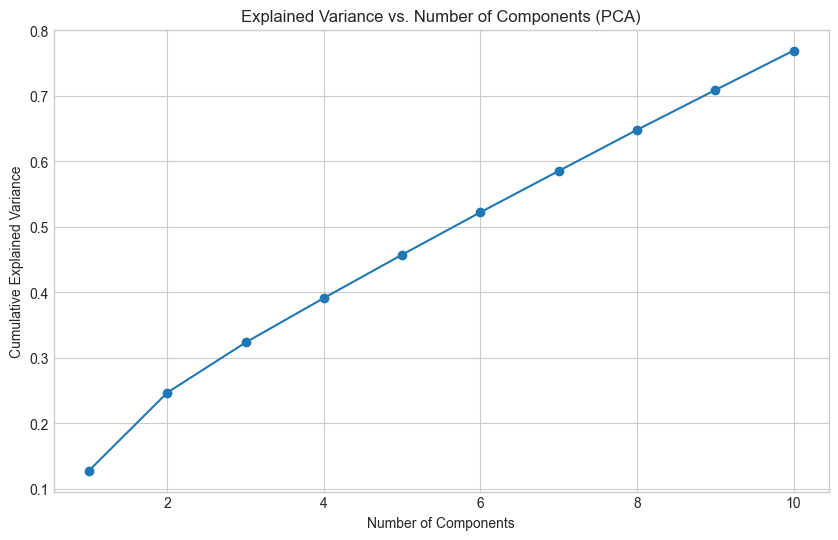

In [177]:
# PCA
n_components = min(10, len(df_model.columns))
pca = PCA(n_components=n_components, random_state=42)
pca_result = pca.fit_transform(df_scaled)

explained_var = pca.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_var) + 1), cumulative_var, marker="o")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance vs. Number of Components (PCA)")
plt.grid(True)
plt.show()



### t-SNE Visualization

t-SNE lets us turn complex data into two dimensions so we can easily see patterns or groups.


Applying t-SNE for visualization...


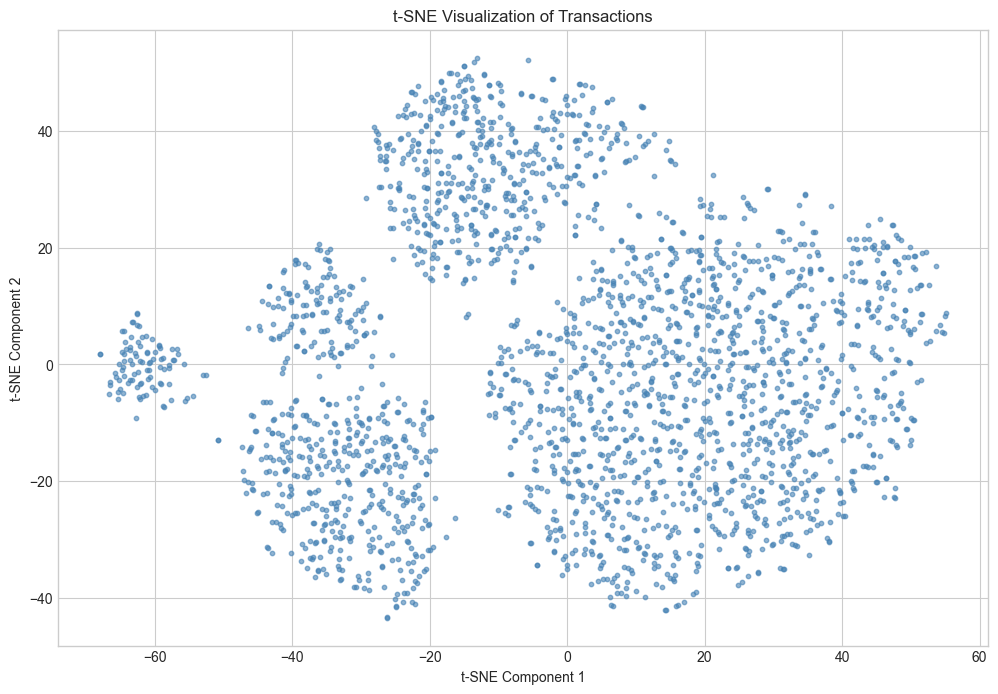

In [178]:
# t-SNE
print("\nApplying t-SNE for visualization...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
tsne_results = tsne.fit_transform(df_scaled)

plt.figure(figsize=(12, 8))
plt.scatter(tsne_results[:, 0], tsne_results[:, 1], s=10, alpha=0.6, c="steelblue")
plt.title("t-SNE Visualization of Transactions")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.show()


## Anomaly Detection Models

With the data cleaned and prepared, we can now use unsupervised methods to spot unusual transactions. Since we don't know which ones are fraud, we'll focus on finding anomalies.

In [179]:
def plot_anomalies(tsne_results, df, label_col, title):
    plt.figure(figsize=(10, 7))
    sns.scatterplot(
        x=tsne_results[:, 0],
        y=tsne_results[:, 1],
        hue=df[label_col],
        palette='coolwarm',
        alpha=0.7
    )
    plt.title(title)
    plt.xlabel("t-SNE Component 1")
    plt.ylabel("t-SNE Component 2")
    plt.legend(title="Anomaly", loc='upper right')
    plt.show()

### Minimum Covariance Determinant (MCD)

The Minimum Covariance Determinant (MCD) finds the main cluster of data and ignores outliers. It's good for data that is mostly normal, and is more robust than other covariance methods. Here, we use 75% of the central data to make the method steady, and mark the top 2.5% of points (with highest Mahalanobis distance) as anomalies.

In [180]:
# Fit Minimum Covariance Determinant (robust covariance estimation)
mcd = MinCovDet(support_fraction=0.75, random_state=42)
mcd.fit(df_scaled_df)

# Compute Mahalanobis distance to the robust center
mahal_dist = mcd.mahalanobis(df_scaled_df)

# Threshold: 97.5th percentile of distances
threshold = np.percentile(mahal_dist, 97.5)

#  Mark anomalies (1 = anomaly, 0 = normal)
df_model["MCD_Anomaly"] = (mahal_dist > threshold).astype(int)
df_model["MCD_Score"] = mahal_dist


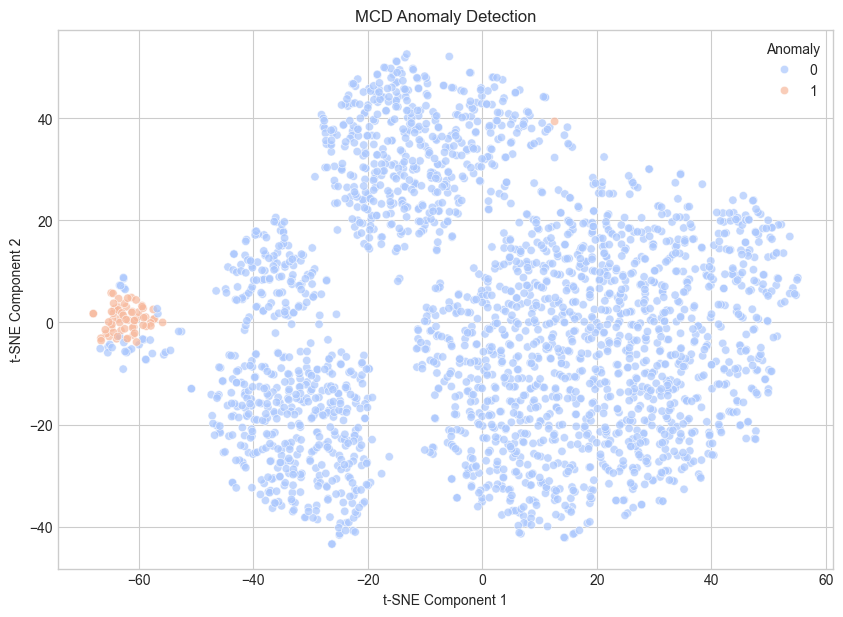

In [181]:
# MCD
plot_anomalies(tsne_results, df_model, 'MCD_Anomaly', "MCD Anomaly Detection")


### Isolation Forest

Isolation Forest finds anomalies by splitting data into random groups. It's good at spotting points that are unusual or uncommon.

In [182]:
param_grid = {
    "n_estimators": [100, 200],       # number of trees
    "contamination": [0.01, 0.02, 0.05],  # anomaly proportion
    "max_samples": [100, "auto"]      # samples per tree
}

iso_forest = IsolationForest(random_state=42)

grid_search = GridSearchCV(
    estimator=iso_forest,             # model
    param_grid=param_grid,            # parameters to try
    cv=3,
    scoring="neg_mean_squared_error",
    verbose=0
)

grid_search.fit(df_scaled_df)
print("Best Isolation Forest parameters:", grid_search.best_params_)

best_iso_forest = grid_search.best_estimator_
df_model["IF_Anomaly"] = best_iso_forest.predict(df_scaled_df)   # labels
df_model["IF_Score"] = best_iso_forest.decision_function(df_scaled_df)  # scores
df_model["IF_Anomaly"] = df_model["IF_Anomaly"].map({1: 0, -1: 1})


Best Isolation Forest parameters: {'contamination': 0.01, 'max_samples': 100, 'n_estimators': 100}


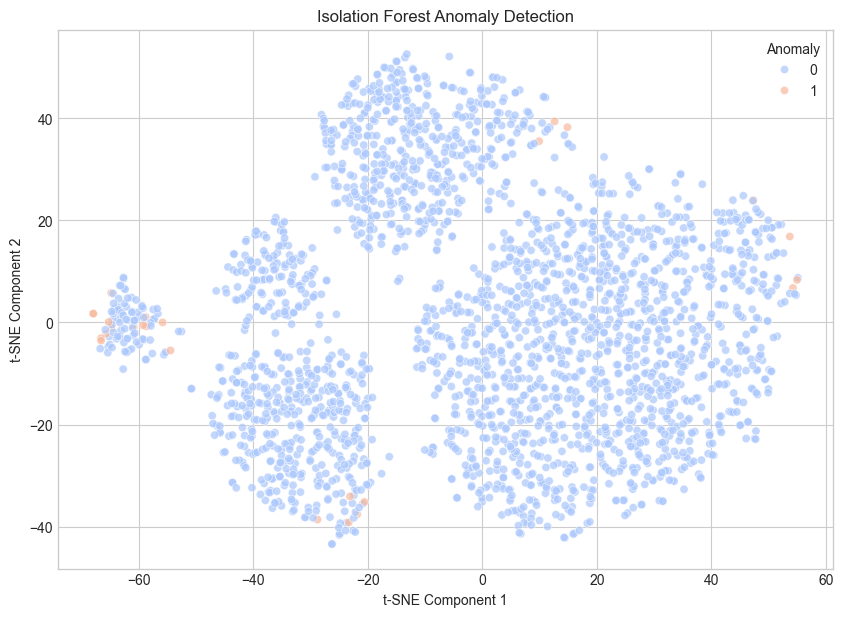

In [183]:
# Isolation Forest
plot_anomalies(tsne_results, df_model, 'IF_Anomaly', "Isolation Forest Anomaly Detection")


###  Local Outlier Factor (LOF)

We used Local Outlier Factor (LOF) for anomaly detection, tuning its settings with GridSearchCV.
We picked the best LOF settings using silhouette score, and tried different numbers of neighbors, contamination rates, and distance metrics.
The final LOF model marks unusual transactions, and we show the results on a t-SNE plot to see how well it finds suspicious activity.

In [184]:
# Custom wrapper to make LOF compatible with GridSearchCV
class LOFWrapper(BaseEstimator, TransformerMixin):
    def __init__(self, n_neighbors=20, contamination=0.05, metric="euclidean"):
        self.n_neighbors = n_neighbors
        self.contamination = contamination
        self.metric = metric
        self.model = None

    def fit(self, X, y=None):
        self.model = LocalOutlierFactor(
            n_neighbors=self.n_neighbors,
            contamination=self.contamination,
            metric=self.metric
        )
        self.labels_ = self.model.fit_predict(X)
        return self

    def predict(self, X):
        # Use fitted labels for training set
        return self.labels_

# Custom scorer: silhouette score (higher = better)
def lof_scorer(estimator, X, y=None):
    labels = estimator.fit(X).labels_
    if len(set(labels)) > 1:  # avoid invalid silhouette case
        return silhouette_score(X, labels)
    else:
        return -1

scorer = make_scorer(lof_scorer, greater_is_better=True)

# GridSearchCV for LOF
param_grid = {
    'n_neighbors': [10, 20, 30, 50],
    'contamination': [0.01, 0.02, 0.05, 0.1],
    'metric': ['euclidean', 'manhattan']
}

grid_search = GridSearchCV(
    estimator=LOFWrapper(),
    param_grid=param_grid,
    scoring=scorer,
    cv=[(np.arange(len(df_scaled_df)), np.arange(len(df_scaled_df)))],
    verbose=1
)

grid_search.fit(df_scaled_df)

print("Best LOF parameters:", grid_search.best_params_)

best_lof = grid_search.best_estimator_
df_model['LOF_Anomaly'] = np.where(best_lof.labels_ == -1, 1, 0)


Fitting 1 folds for each of 32 candidates, totalling 32 fits
Best LOF parameters: {'contamination': 0.01, 'metric': 'euclidean', 'n_neighbors': 10}


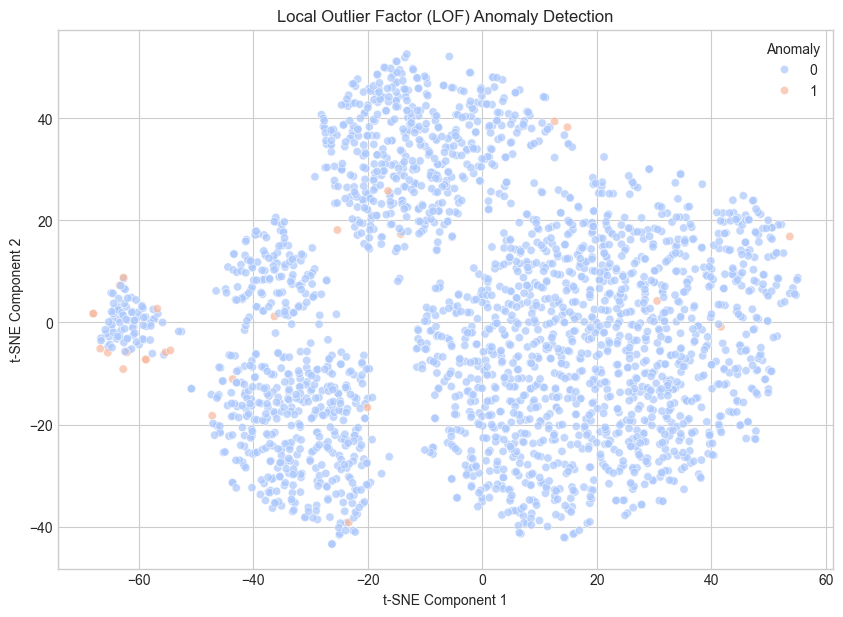

In [185]:
plot_anomalies(tsne_results, df_model, 'LOF_Anomaly', "Local Outlier Factor (LOF) Anomaly Detection")

### One-Class SVM

Finds which transactions are normal; others are labeled as anomalies.

In [186]:
ocsvm = OneClassSVM(nu=0.05, kernel="rbf", gamma="auto")
df_model['OCSVM_Anomaly'] = ocsvm.fit_predict(df_scaled_df)
df_model['OCSVM_Score'] = ocsvm.decision_function(df_scaled_df)

# Map: -1 → anomaly (1), 1 → normal (0)
df_model['OCSVM_Anomaly'] = df_model['OCSVM_Anomaly'].map({1: 0, -1: 1})


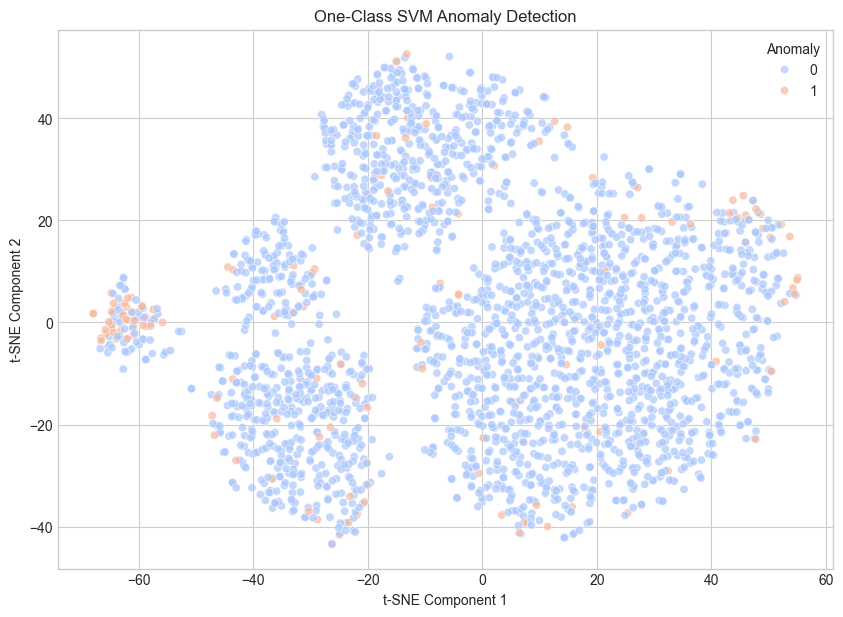

In [187]:
plot_anomalies(tsne_results, df_model, 'OCSVM_Anomaly', "One-Class SVM Anomaly Detection")

### Ensemble Voting

We then combine the methods using majority voting.

Ensemble Anomalies (majority vote): 55 (2.19%)


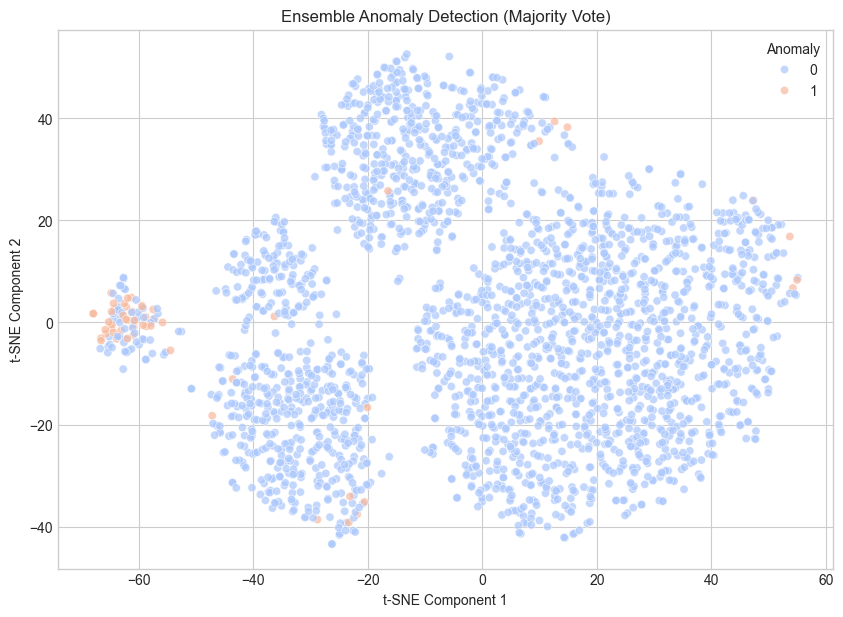

In [188]:
# Ensemble anomaly detection (majority vote)
df_model['Ensemble_Anomaly'] = (
    (df_model['IF_Anomaly'] + df_model['LOF_Anomaly'] + df_model['OCSVM_Anomaly']+df_model['MCD_Anomaly']) >= 2
).astype(int)

print(f"Ensemble Anomalies (majority vote): {df_model['Ensemble_Anomaly'].sum()} "
      f"({df_model['Ensemble_Anomaly'].mean()*100:.2f}%)")

# Visualization
plot_anomalies(tsne_results, df_model, 'Ensemble_Anomaly', 
               "Ensemble Anomaly Detection (Majority Vote)")


## SHAP Analysis

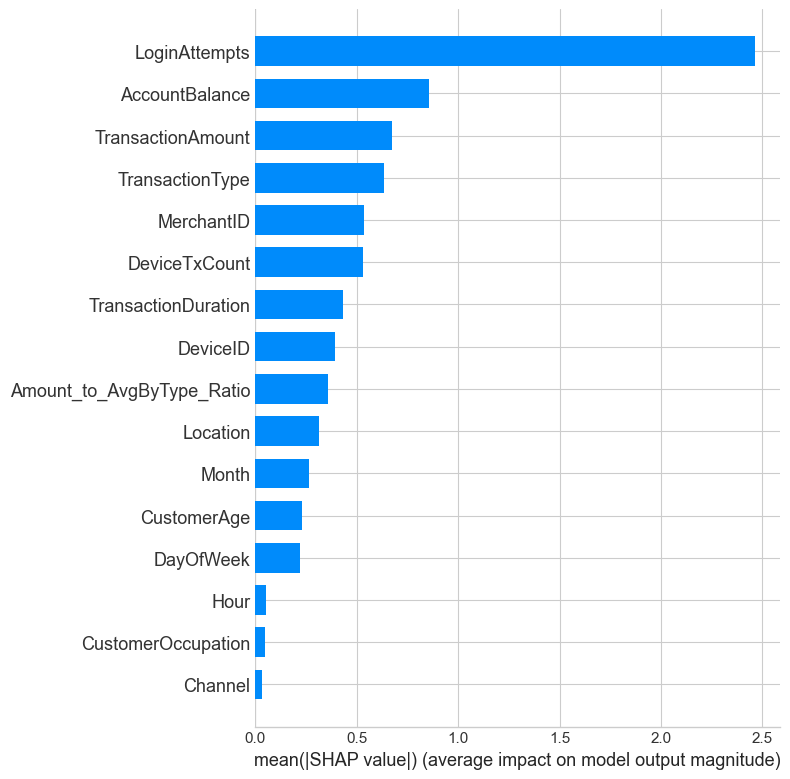

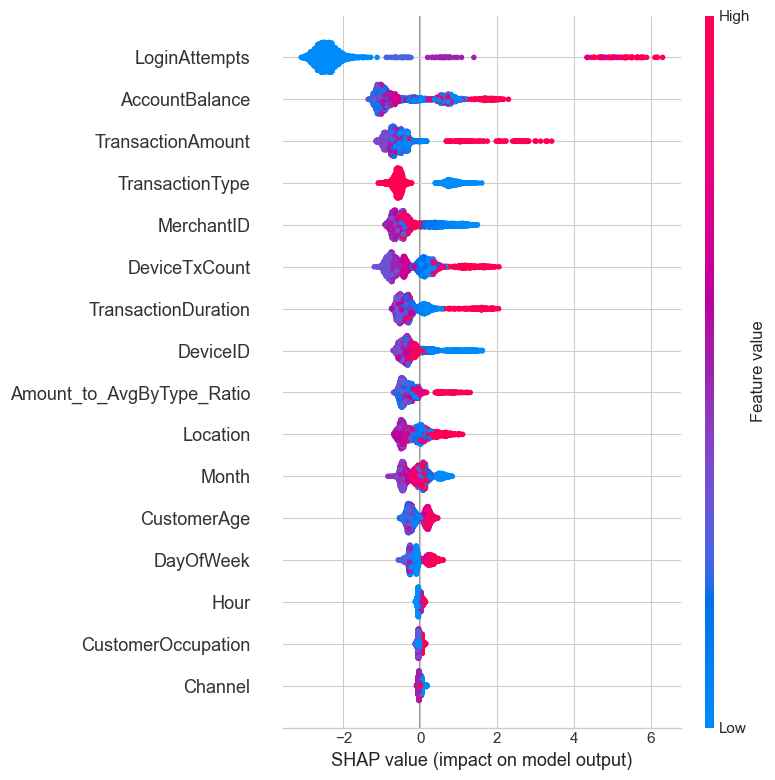

In [189]:
# Define features and labels
X = df_model.drop([
    'IF_Anomaly','LOF_Anomaly','MCD_Score','MCD_Anomaly',
    'OCSVM_Anomaly','IF_Score','OCSVM_Score','Ensemble_Anomaly'
], axis=1)
y = df_model['Ensemble_Anomaly']

# Train XGBoost model
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X, y)

# === SHAP values ===
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X)

# Summary plot
shap.summary_plot(shap_values, X, plot_type="bar")

# Detailed beeswarm plot
shap.summary_plot(shap_values, X)


By using the shap value we can see that the most predictive feature is LoginAttempts. followed by AccountBalance and TransactionAmount. We can see this as the model learn from the user account activities and information.

### Decision Tree for Anomaly Detection Rules
We use a simple Decision Tree on the combined anomaly labels to get clear, easy-to-read rules for spotting unusual transactions. Unlike other more complex models, this tree shows exactly which things cause a transaction to be marked as suspicious.

These rules show that most anomalies are linked to unusual spending and strange login behavior. For example, if someone tries to log in many times or spends much more or less than usual, it usually gets flagged. Other signals include odd account balances, devices, or merchants.

This approach gives us clear "if-then" rules (like: "IF high login attempts AND abnormal amount, THEN anomaly"). These rules make it easy for fraud analysts to understand and check why a transaction gets flagged, giving both transparency and useful guidance.

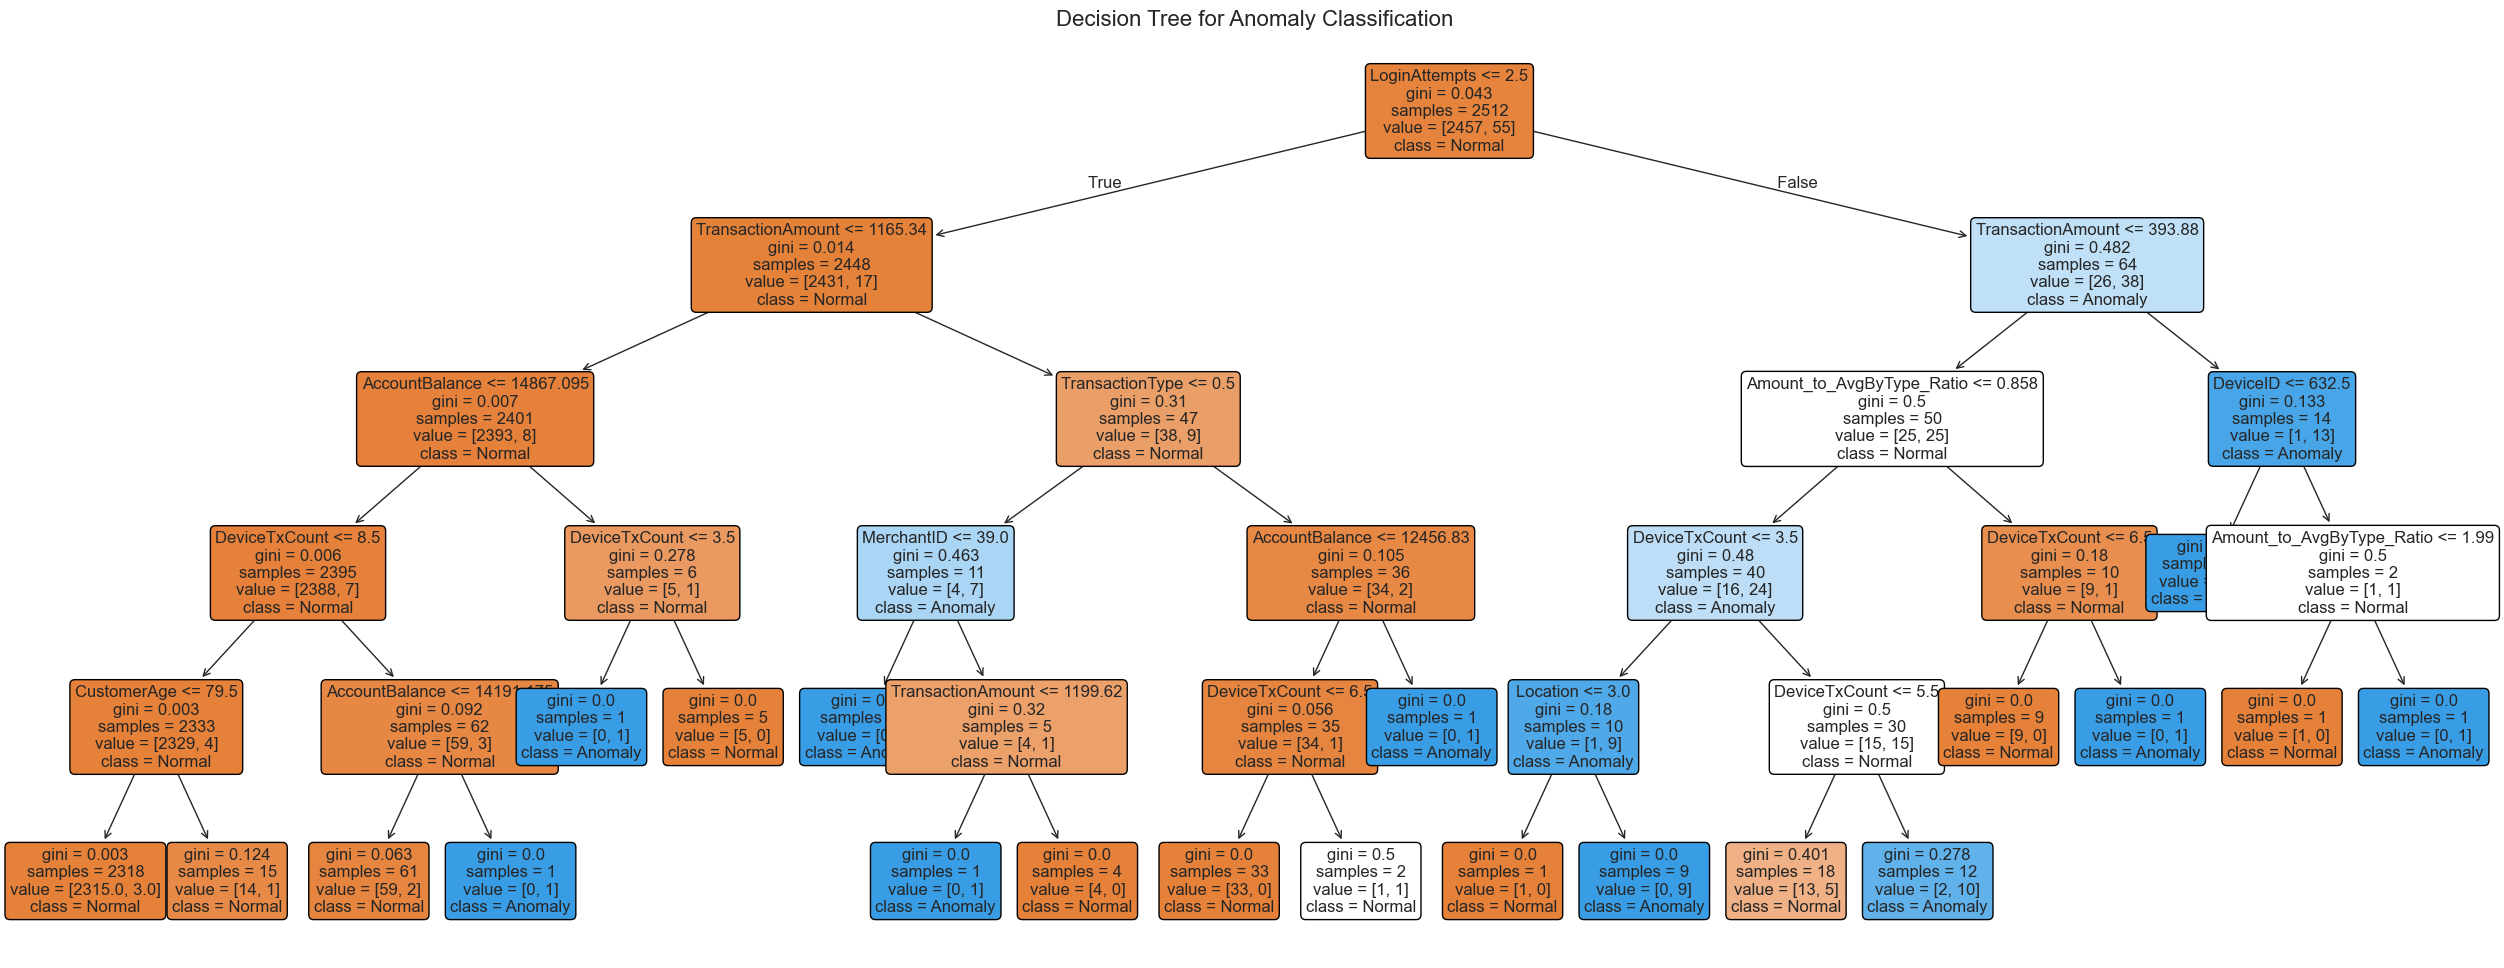


Decision Rules for Identifying Anomalies:

|--- LoginAttempts <= 2.50
|   |--- TransactionAmount <= 1165.34
|   |   |--- AccountBalance <= 14867.09
|   |   |   |--- DeviceTxCount <= 8.50
|   |   |   |   |--- CustomerAge <= 79.50
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- CustomerAge >  79.50
|   |   |   |   |   |--- class: 0
|   |   |   |--- DeviceTxCount >  8.50
|   |   |   |   |--- AccountBalance <= 14191.17
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- AccountBalance >  14191.17
|   |   |   |   |   |--- class: 1
|   |   |--- AccountBalance >  14867.09
|   |   |   |--- DeviceTxCount <= 3.50
|   |   |   |   |--- class: 1
|   |   |   |--- DeviceTxCount >  3.50
|   |   |   |   |--- class: 0
|   |--- TransactionAmount >  1165.34
|   |   |--- TransactionType <= 0.50
|   |   |   |--- MerchantID <= 39.00
|   |   |   |   |--- class: 1
|   |   |   |--- MerchantID >  39.00
|   |   |   |   |--- TransactionAmount <= 1199.62
|   |   |   |   |   |--- class: 1
|   |   |   |   

In [190]:
# Train simple decision tree
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X, y)

# Visualize tree
plt.figure(figsize=(32, 12))
plot_tree(
    dt, 
    filled=True, 
    feature_names=X.columns, 
    class_names=["Normal","Anomaly"], 
    rounded=True,
    fontsize=12
)
plt.title("Decision Tree for Anomaly Classification", fontsize=16)
plt.show()


# Extract decision rules
rules = export_text(dt, feature_names=list(X.columns))
print("\nDecision Rules for Identifying Anomalies:\n")
print(rules)


In [191]:
# Export joblib bundle for `anomaly_tree_inference_api.py` (no separate training run needed)
import joblib
from pathlib import Path

_export_path = Path("artifacts/dt_inference_bundle.joblib")
avg_amount_by_type = (
    _df_pre_encode_for_api.groupby("TransactionType")["TransactionAmount"]
    .mean()
    .astype(float)
    .to_dict()
)
_device_tx_count_map = (
    _df_pre_encode_for_api.groupby("DeviceID")
    .size()
    .astype(int)
    .to_dict()
)
_inference_bundle = {
    "decision_tree": dt,
    "feature_names": list(X.columns),
    "label_encoders": label_encoders,
    "avg_amount_by_type": avg_amount_by_type,
    "device_tx_count": _device_tx_count_map,
    "meta": {
        "notebook": "transaction_risk_profile.ipynb",
        "tree_max_depth": dt.max_depth,
    },
}
_export_path.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(_inference_bundle, _export_path)
print(f"Saved FastAPI inference bundle to {_export_path.resolve()}")

Saved FastAPI inference bundle to C:\Users\Admin\Desktop\devoteam_test\artifacts\dt_inference_bundle.joblib


# Question 3

Build a productionized API inference for the model using FastAPI, UV for package management, and pydantic data model.

you can run the API by `uv sync` then `py -m uvicorn anomaly_tree_inference_api:app --host 127.0.0.1 --port 8000` to start the server, you can then test the endpoint by using the code below.



In [5]:
import requests

url = "http://127.0.0.1:8000/v1/predict"
headers = {"Content-Type": "application/json"}
payload = {
    "transactions": [
        {
            "transaction_amount": 14.09,
            "transaction_type": "Debit",
            "location": "San Diego",
            "device_id": "D000380",
            "merchant_id": "M015",
            "channel": "ATM",
            "customer_age": 70,
            "customer_occupation": "Doctor",
            "transaction_duration": 81,
            "login_attempts": 1,
            "account_balance": 5112.21,
            "transaction_date": "2023-04-11 16:29:14"
        }
    ]
}

response = requests.post(url, json=payload, headers=headers)
if response.ok:
    print("API response:", response.json())
else:
    print("Failed with status code", response.status_code, "-", response.text)

API response: {'predictions': [{'label': 0, 'proba_normal': 0.9987057808455565, 'proba_anomaly': 0.0012942191544434857}]}
